# BetaGDD — Training & Synthetic Recovery

Two goals:

1. Train `GlobalBetaGDDModel` on *Prunus yedoensis* (Japan) and inspect the learned parameters.
2. **Synthetic recovery test**: generate bloom timing from a model with *known* parameters, fit a
   fresh model to that synthetic data, and verify the optimizer recovers the ground truth.
   This validates that the forward pass, loss, and optimizer are all working correctly —
   independently of whether real data has enough signal.

## Config

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from pysephone.constants import KEY_DATA_SOURCE, KEY_FEATURES, KEY_LOC_ID, KEY_YEAR
from pysephone.dataset.dataset import Dataset
from pysephone.dataset.util.calendar import Calendar
from pysephone.dataset.util.feature_cache import FeatureCache
from pysephone.evaluation.regression import SingleTargetRegression
from pysephone.models.beta_gdd import GlobalBetaGDDModel

OBS_KEY = 'gmu_0'
CUTOFF  = 2015
DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Device: cuda


## 1. Load data

In [50]:
cal    = Calendar(default_start='10-01', default_length=365)
_cache = FeatureCache.load(FeatureCache.default_path('GMU_Cherry_Japan_YS', ['temperature_2m_mean']))
ds_all = Dataset.load('GMU_Cherry_Japan_YS', calendar=cal, feature_providers=[_cache])
ds_y   = ds_all.select_species([('GMU_cherry', 0)])   # Prunus yedoensis only

target_fn = lambda s: s['observations'][OBS_KEY]

years_trn = [y for y in ds_y.years if y < CUTOFF]
years_tst = [y for y in ds_y.years if y >= CUTOFF]
ds_trn = ds_y.select_years(years_trn)
ds_tst = ds_y.select_years(years_tst)

print(f'Train: {len(ds_trn)} samples  ({min(years_trn)}–{max(years_trn)})')
print(f'Test:  {len(ds_tst)} samples  ({min(years_tst)}–{max(years_tst)})')

Train: 1717 samples  (1986–2014)
Test:  280 samples  (2015–2021)


## 2. Train GlobalBetaGDDModel

In [51]:

model, fit_info = GlobalBetaGDDModel.fit(
    target_fn        = target_fn,
    dataset          = ds_trn,
    model_kwargs     = dict(
        t_low             = -5.0,
        t_high            = 20.0,
        learn_bounds      = True,
        bounds_reg_lambda = 0.01,
        bounds_min_width  = 5.0,
        alpha_init        = 2.0,
        beta_init         = 2.0,
        learn_alpha_beta  = True,
        learn_t_base      = True,
        t_base_init       = 5.0,
        learn_thresholds  = True,
    ),
    num_epochs               = 1000,
    batch_size               = 512,
    val_period               = 10,
    optimizer                = 'adam',
    optimizer_kwargs         = dict(lr=1e-3, weight_decay=1e-4),
    scheduler_step_size      = 100,
    scheduler_decay          = 0.9,
    early_stopping           = True,
    early_stopping_patience  = 10,
    early_stopping_min_delta = 1e-4,
    device  = DEVICE,
    verbose = True,
)
print('Done.')


GlobalBetaGDDModel epoch [    1/1000] lr=1.00e-03 loss=0.41550: 100%|██████████| 3/3 [00:00<00:00, 112.18it/s]
GlobalBetaGDDModel epoch [    2/1000] lr=1.00e-03 loss=0.41352: 100%|██████████| 3/3 [00:00<00:00, 109.40it/s]
GlobalBetaGDDModel epoch [    3/1000] lr=1.00e-03 loss=0.40827: 100%|██████████| 3/3 [00:00<00:00, 78.96it/s]
GlobalBetaGDDModel epoch [    4/1000] lr=1.00e-03 loss=0.40599: 100%|██████████| 3/3 [00:00<00:00, 78.27it/s]
GlobalBetaGDDModel epoch [    5/1000] lr=1.00e-03 loss=0.40069: 100%|██████████| 3/3 [00:00<00:00, 77.50it/s]
GlobalBetaGDDModel epoch [    6/1000] lr=1.00e-03 loss=0.39235: 100%|██████████| 3/3 [00:00<00:00, 96.33it/s]
GlobalBetaGDDModel epoch [    7/1000] lr=1.00e-03 loss=0.39257: 100%|██████████| 3/3 [00:00<00:00, 119.93it/s]
GlobalBetaGDDModel epoch [    8/1000] lr=1.00e-03 loss=0.39046: 100%|██████████| 3/3 [00:00<00:00, 124.97it/s]
GlobalBetaGDDModel epoch [    9/1000] lr=1.00e-03 loss=0.38202: 100%|██████████| 3/3 [00:00<00:00, 125.51it/s]
Globa

Done.


## 3. Inspect learned parameters

In [52]:
α     = model.alpha.item()
β     = model.beta.item()
t_low = model.t_low_eff.item()
t_hi  = model.t_high_eff.item()
t_opt = t_low + (t_hi - t_low) * (α - 1) / (α + β - 2)
t_base = model._gdd._tb.item()

print(f'α       = {α:.3f}  (init 2.0)')
print(f'β       = {β:.3f}  (init 2.0)')
print(f't_low   = {t_low:.2f} °C')
print(f't_high  = {t_hi:.2f} °C')
print(f'T_opt   = {t_opt:.2f} °C')
print(f't_base  = {t_base:.2f} °C')

α       = 1.753  (init 2.0)
β       = 1.529  (init 2.0)
t_low   = -4.53 °C
t_high  = 19.33 °C
T_opt   = 9.48 °C
t_base  = 5.27 °C


In [53]:
res = SingleTargetRegression.run(
    model=model, dataset_train=ds_trn, dataset_test=ds_tst,
    target_fn=target_fn, run_name='GlobalBetaGDD',
)
m = res.compute_metrics()
for split in ('train', 'test'):
    mm = m[split]
    print(f"{split:5s}  RMSE={mm['rmse']:.2f}  MAE={mm['mae']:.2f}  R²={mm['r2']:.3f}")

train  RMSE=10.26  MAE=5.54  R²=-0.105
test   RMSE=5.74  MAE=4.39  R²=0.544


## 4. Synthetic recovery test

Build a *ground truth* model with known parameters (deliberately different from
the real fit), run it on the training temperature data to produce synthetic bloom
dates, then fit a fresh model from default initialisation to those synthetic dates.

If recovery succeeds (learned ≈ ground truth), the implementation is correct.
If it fails, there is a bug or the loss landscape is too degenerate to optimise.

In [54]:

from pysephone.models.torch_base import BaseTorchModel

# --- Ground truth parameters (known, different from defaults) ---
GT = dict(
    alpha_init       = 3.0,
    beta_init        = 2.0,
    learn_alpha_beta = False,
    t_low            = -2.0,
    t_high           = 14.0,
    learn_bounds     = False,
    t_base_init      = 3.5,
    learn_t_base     = False,
    learn_thresholds = False,
)

gt_model = GlobalBetaGDDModel(**GT).to(DEVICE)
gt_model.eval()

dl = GlobalBetaGDDModel._make_dataloader(ds_trn, batch_size=512, shuffle=False)

synth_doys = {}
with torch.no_grad():
    for xs in dl:
        xs = BaseTorchModel._batch_to_device(xs, torch.device(DEVICE))
        pred_ix, _ = gt_model(xs)
        for src, loc_id, year, doy in zip(
            xs[KEY_DATA_SOURCE],
            xs[KEY_LOC_ID],
            xs[KEY_YEAR],
            pred_ix.cpu().tolist(),
        ):
            synth_doys[(src, loc_id, int(year))] = doy

print(f'Generated {len(synth_doys)} synthetic bloom dates.')
doys = list(synth_doys.values())
print(f'DOY range: {min(doys):.0f} – {max(doys):.0f},  mean {np.mean(doys):.1f}')


Generated 1717 synthetic bloom dates.
DOY range: 188 – 364,  mean 240.0


In [55]:

# target_fn is called per-sample by the loss function (not batched).
# It must return a date; the loss converts it to a season index internally.
def synth_target_fn(sample):
    src    = sample[KEY_DATA_SOURCE]
    loc_id = sample[KEY_LOC_ID]
    year   = int(sample[KEY_YEAR])
    ix     = int(round(synth_doys[(src, loc_id, year)]))
    return np.datetime64(sample['season_start'], 'D') + np.timedelta64(ix, 'D')

# Fit a fresh model — only alpha/beta and thresholds are learned; bounds fixed at GT values
rec_model, rec_fit = GlobalBetaGDDModel.fit(
    target_fn    = synth_target_fn,
    dataset      = ds_trn,
    model_kwargs = dict(
        t_low            = GT['t_low'],    # fixed at ground-truth bounds
        t_high           = GT['t_high'],
        learn_bounds     = False,
        alpha_init       = 2.0,            # start away from GT (3.0, 2.0)
        beta_init        = 2.0,
        learn_alpha_beta = True,
        learn_t_base     = True,
        t_base_init      = 5.0,
        learn_thresholds = True,
    ),
    num_epochs               = 1000,
    batch_size               = 512,
    val_period               = 10,
    optimizer                = 'adam',
    optimizer_kwargs         = dict(lr=1e-3, weight_decay=1e-4),
    scheduler_step_size      = 100,
    scheduler_decay          = 0.9,
    early_stopping           = True,
    early_stopping_patience  = 10,
    early_stopping_min_delta = 1e-4,
    device  = DEVICE,
    verbose = True,
)
print('Done.')


GlobalBetaGDDModel epoch [    1/1000] lr=1.00e-03 loss=2.44591: 100%|██████████| 3/3 [00:00<00:00, 129.67it/s]
GlobalBetaGDDModel epoch [    2/1000] lr=1.00e-03 loss=2.56085: 100%|██████████| 3/3 [00:00<00:00, 135.74it/s]
GlobalBetaGDDModel epoch [    3/1000] lr=1.00e-03 loss=2.48199: 100%|██████████| 3/3 [00:00<00:00, 129.74it/s]
GlobalBetaGDDModel epoch [    4/1000] lr=1.00e-03 loss=2.68644: 100%|██████████| 3/3 [00:00<00:00, 131.02it/s]
GlobalBetaGDDModel epoch [    5/1000] lr=1.00e-03 loss=2.52510: 100%|██████████| 3/3 [00:00<00:00, 145.18it/s]
GlobalBetaGDDModel epoch [    6/1000] lr=1.00e-03 loss=2.66128: 100%|██████████| 3/3 [00:00<00:00, 124.77it/s]
GlobalBetaGDDModel epoch [    7/1000] lr=1.00e-03 loss=2.63610: 100%|██████████| 3/3 [00:00<00:00, 90.59it/s]
GlobalBetaGDDModel epoch [    8/1000] lr=1.00e-03 loss=2.73625: 100%|██████████| 3/3 [00:00<00:00, 82.72it/s]
GlobalBetaGDDModel epoch [    9/1000] lr=1.00e-03 loss=2.55537: 100%|██████████| 3/3 [00:00<00:00, 109.18it/s]
Glo

Done.


In [56]:

def _t_opt(alpha, beta, t_low, t_high):
    return t_low + (t_high - t_low) * (alpha - 1) / (alpha + beta - 2)

# Init values as passed to the recovery model
INIT = dict(alpha=2.0, beta=2.0, t_low=GT['t_low'], t_high=GT['t_high'],
            T_opt=_t_opt(2.0, 2.0, GT['t_low'], GT['t_high']), t_base=5.0)
GT_vals = dict(alpha=GT['alpha_init'], beta=GT['beta_init'],
               t_low=GT['t_low'], t_high=GT['t_high'],
               T_opt=_t_opt(GT['alpha_init'], GT['beta_init'], GT['t_low'], GT['t_high']),
               t_base=GT['t_base_init'])
REC = dict(alpha=rec_model.alpha.item(), beta=rec_model.beta.item(),
           t_low=rec_model.t_low_eff.item(), t_high=rec_model.t_high_eff.item(),
           T_opt=_t_opt(rec_model.alpha.item(), rec_model.beta.item(),
                        rec_model.t_low_eff.item(), rec_model.t_high_eff.item()),
           t_base=rec_model._gdd._tb.item())

df_cmp = pd.DataFrame({
    'init':         INIT,
    'ground_truth': GT_vals,
    'recovered':    REC,
}).round(3)
df_cmp['error'] = (df_cmp['recovered'] - df_cmp['ground_truth']).round(3)
print(df_cmp.to_string())


        init  ground_truth  recovered  error
alpha    2.0         3.000      2.602 -0.398
beta     2.0         2.000      1.674 -0.326
t_low   -2.0        -2.000     -2.000  0.000
t_high  14.0        14.000     14.000  0.000
T_opt    6.0         8.667      9.265  0.598
t_base   5.0         3.500      5.798  2.298


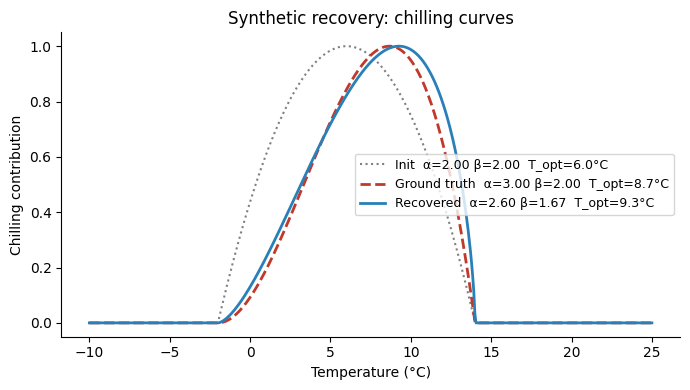

In [57]:

T_GRID = np.linspace(-10, 25, 500)
eps = 1e-6

def beta_curve(alpha, beta, t_low, t_high, T):
    T_norm = np.clip((T - t_low) / (t_high - t_low + eps), eps, 1 - eps)
    lc = (alpha - 1) * np.log(T_norm) + (beta - 1) * np.log(1 - T_norm)
    mode = np.clip((alpha - 1) / (alpha + beta - 2), eps, 1 - eps)
    lm = (alpha - 1) * np.log(mode) + (beta - 1) * np.log(1 - mode)
    return np.where((T >= t_low) & (T <= t_high), np.exp(lc - lm), 0.0)

fig, ax = plt.subplots(figsize=(7, 4))

for label, vals, color, ls, lw in [
    ('Init',         INIT,    'grey',    ':',  1.5),
    ('Ground truth', GT_vals, '#c0392b', '--', 2.0),
    ('Recovered',    REC,     '#2980b9', '-',  2.0),
]:
    curve = beta_curve(vals['alpha'], vals['beta'], vals['t_low'], vals['t_high'], T_GRID)
    ax.plot(T_GRID, curve, color=color, ls=ls, lw=lw,
            label=f'{label}  α={vals["alpha"]:.2f} β={vals["beta"]:.2f}  T_opt={vals["T_opt"]:.1f}°C')

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Chilling contribution')
ax.set_title('Synthetic recovery: chilling curves')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## 5. Identifiability: profile loss over α and β

Fix α (or β) to a grid of values, optimise all other parameters to convergence for
each, and record the minimum validation loss.  A clear dip indicates the data
identifies that parameter.  A flat curve means equifinality — many values give
equally good fits.

In [58]:
from tqdm.auto import tqdm

def _best_val_loss(fit_info):
    vals = [e['val']['loss'] for e in fit_info['epochs'] if 'val' in e]
    return min(vals) if vals else fit_info['epochs'][-1]['loss']

def profile_over(param, grid, ds, t_fn, device, num_epochs=500, patience=5):
    """For each value in grid, fix `param` ('alpha' or 'beta') and fit everything else.
    Returns list of best val losses, one per grid point."""
    assert param in ('alpha', 'beta')
    losses = []
    for val in tqdm(grid, desc=f'Profile α' if param == 'alpha' else 'Profile β'):
        m = GlobalBetaGDDModel(
            alpha_init   = float(val) if param == 'alpha' else 2.0,
            beta_init    = float(val) if param == 'beta'  else 2.0,
            learn_alpha_beta = True,
            t_low=-5.0, t_high=20.0, learn_bounds=True, bounds_min_width=5.0,
            learn_t_base=True, t_base_init=5.0, learn_thresholds=True,
        ).to(device)
        # Freeze the profiled parameter; everything else remains trainable
        if param == 'alpha':
            m._raw_alpha.requires_grad_(False)
        else:
            m._raw_beta.requires_grad_(False)
        _, fi = GlobalBetaGDDModel.fit(
            target_fn        = t_fn,
            dataset          = ds,
            model            = m,
            num_epochs       = num_epochs,
            batch_size       = 512,
            val_period       = 5,
            optimizer        = 'adam',
            optimizer_kwargs = dict(lr=1e-3, weight_decay=1e-4),
            early_stopping           = True,
            early_stopping_patience  = patience,
            early_stopping_min_delta = 1e-4,
            device  = device,
            verbose = False,
        )
        losses.append(_best_val_loss(fi))
    return losses

GRID = np.linspace(1.1, 6.0, 25)

alpha_losses = profile_over('alpha', GRID, ds_trn, target_fn, DEVICE)
beta_losses  = profile_over('beta',  GRID, ds_trn, target_fn, DEVICE)

Profile α:   0%|          | 0/25 [00:00<?, ?it/s]

Profile β:   0%|          | 0/25 [00:00<?, ?it/s]

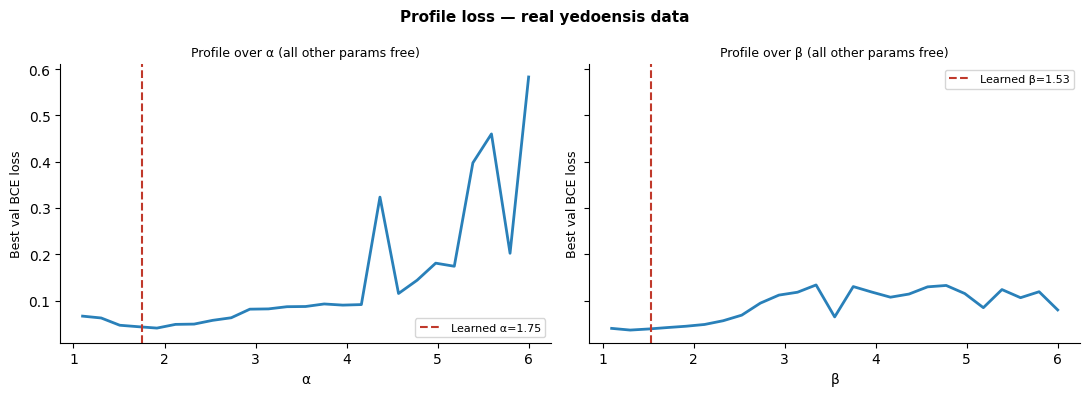

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
fig.suptitle('Profile loss — real yedoensis data', fontsize=11, fontweight='bold')

for ax, losses, param, learned_val in [
    (axes[0], alpha_losses, 'α', model.alpha.item()),
    (axes[1], beta_losses,  'β', model.beta.item()),
]:
    ax.plot(GRID, losses, color='#2980b9', lw=2)
    ax.axvline(learned_val, color='#c0392b', lw=1.5, ls='--',
               label=f'Learned {param}={learned_val:.2f}')
    ax.set_xlabel(param, fontsize=10)
    ax.set_ylabel('Best val BCE loss', fontsize=9)
    ax.set_title(f'Profile over {param} (all other params free)', fontsize=9)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Quantitative identifiability metrics

Two complementary metrics per parameter:

1. **Curvature at minimum** — second derivative of the profile loss at its argmin (finite differences).
   Higher curvature → the loss responds more sharply to deviations → better identified.

2. **Profile CI width** — width of the set `{θ : L(θ) ≤ L_min + δ}` for a chosen `δ`.
   Narrow interval → tight constraint on the parameter.  Analogous to a likelihood-ratio confidence interval.

In [60]:
def identifiability_metrics(grid, losses, delta=0.01):
    """
    grid:   1-D array of parameter values
    losses: 1-D array of best-val losses (same length)
    delta:  loss threshold above the minimum for CI width

    Returns dict with:
        argmin     - parameter value at minimum loss
        min_loss   - minimum loss
        curvature  - second derivative at argmin (finite differences, normalised by grid spacing)
        ci_width   - width of {theta : loss <= min_loss + delta}
        ci_lo, ci_hi - bounds of that interval
    """
    grid   = np.asarray(grid,   dtype=float)
    losses = np.asarray(losses, dtype=float)

    i_min    = np.argmin(losses)
    min_loss = losses[i_min]
    argmin   = grid[i_min]

    # Second derivative via central finite differences (use neighbours if interior)
    if 0 < i_min < len(grid) - 1:
        h  = grid[i_min + 1] - grid[i_min - 1]   # 2 * spacing (may be irregular)
        d2 = (losses[i_min + 1] - 2 * losses[i_min] + losses[i_min - 1]) / (h / 2) ** 2
    else:
        d2 = float('nan')

    # Profile CI: contiguous region containing argmin where loss <= min_loss + delta
    in_ci = losses <= min_loss + delta
    # Find the contiguous block that includes i_min
    lo, hi = i_min, i_min
    while lo > 0 and in_ci[lo - 1]:
        lo -= 1
    while hi < len(grid) - 1 and in_ci[hi + 1]:
        hi += 1

    ci_lo    = grid[lo]
    ci_hi    = grid[hi]
    ci_width = ci_hi - ci_lo

    return dict(argmin=argmin, min_loss=min_loss, curvature=d2,
                ci_lo=ci_lo, ci_hi=ci_hi, ci_width=ci_width)


DELTA = 0.005   # loss units above minimum that define the CI

rows = {}
for param, losses_arr in [('α', alpha_losses), ('β', beta_losses)]:
    m = identifiability_metrics(GRID, losses_arr, delta=DELTA)
    rows[param] = m

df_id = pd.DataFrame(rows).T[['argmin', 'min_loss', 'curvature', 'ci_lo', 'ci_hi', 'ci_width']].round(4)
df_id.index.name = 'param'
print(f"Profile identifiability metrics  (CI threshold δ={DELTA})")
print(df_id.to_string())
print()
print("Interpretation:")
print("  curvature  : higher → sharper minimum → parameter better constrained by data")
print("  ci_width   : narrower → tighter CI → parameter better identified")


Profile identifiability metrics  (CI threshold δ=0.005)
       argmin  min_loss  curvature   ci_lo   ci_hi  ci_width
param                                                       
α      1.9167    0.0405     0.2623  1.7125  1.9167    0.2042
β      1.3042    0.0362     0.1447  1.1000  1.5083    0.4083

Interpretation:
  curvature  : higher → sharper minimum → parameter better constrained by data
  ci_width   : narrower → tighter CI → parameter better identified


## 6. Profile loss over threshold parameters

Same profiling approach but for the two soft-threshold parameters:

- **Chilling threshold** (`_tt_unit_threshold`): accumulated beta-weighted chill units required before forcing starts.  Physical value = normalized threshold × 200.
- **GDD threshold** (`_gdd_threshold`): accumulated masked GDD units required to trigger bloom.  Physical value = normalized threshold × 500.

Shape parameters α, β and bounds are free to compensate — same "margin over minimum" CI logic as before.

In [61]:
def profile_over_threshold(which, grid_norm, ds, t_fn, device, num_epochs=500, patience=5):
    """Fix one threshold (normalised) to each grid value; optimise all other params.

    which:      'chilling' or 'gdd'
    grid_norm:  values in normalised threshold space (~0–1)
    """
    assert which in ('chilling', 'gdd')
    losses = []
    for val in tqdm(grid_norm,
                    desc='Profile chilling threshold' if which == 'chilling'
                         else 'Profile GDD threshold'):
        m = GlobalBetaGDDModel(
            alpha_init=2.0, beta_init=2.0, learn_alpha_beta=True,
            t_low=-5.0, t_high=20.0, learn_bounds=True, bounds_min_width=5.0,
            learn_t_base=True, t_base_init=5.0,
            learn_thresholds=True,
        ).to(device)

        if which == 'chilling':
            m._tt_unit_threshold._threshold.data.fill_(float(val))
            m._tt_unit_threshold._threshold.requires_grad_(False)
        else:
            m._gdd_threshold._threshold.data.fill_(float(val))
            m._gdd_threshold._threshold.requires_grad_(False)

        _, fi = GlobalBetaGDDModel.fit(
            target_fn=t_fn, dataset=ds, model=m,
            num_epochs=num_epochs, batch_size=512, val_period=5,
            optimizer='adam', optimizer_kwargs=dict(lr=1e-3, weight_decay=1e-4),
            early_stopping=True, early_stopping_patience=patience,
            early_stopping_min_delta=1e-4, device=device, verbose=False,
        )
        losses.append(_best_val_loss(fi))
    return losses


# Normalised grid [0.05, 0.95]; physical: chilling ×200, GDD ×500
THRESH_GRID = np.linspace(0.05, 0.95, 25)

chill_losses = profile_over_threshold('chilling', THRESH_GRID, ds_trn, target_fn, DEVICE)
gdd_losses   = profile_over_threshold('gdd',      THRESH_GRID, ds_trn, target_fn, DEVICE)

Profile chilling threshold:   0%|          | 0/25 [00:00<?, ?it/s]

Profile GDD threshold:   0%|          | 0/25 [00:00<?, ?it/s]

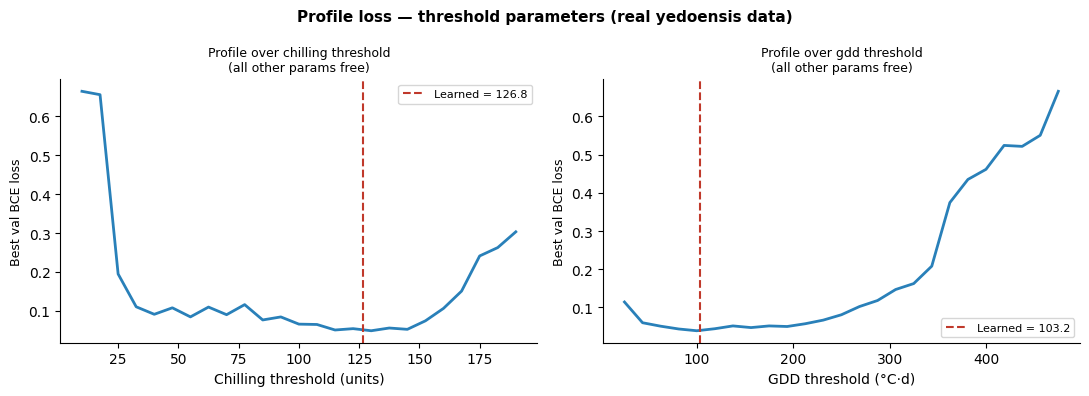


Profile identifiability metrics  (CI threshold δ=0.005)
              argmin  min_loss  curvature   ci_lo  ci_hi  ci_width
param                                                             
chill_thresh   130.0    0.0491     0.0002  130.00  130.0      0.00
gdd_thresh     100.0    0.0391     0.0000   81.25  100.0     18.75


In [62]:
# Convert normalised grid to physical units for display
chill_grid_phys = THRESH_GRID * 200.0   # chilling units
gdd_grid_phys   = THRESH_GRID * 500.0   # GDD units

# Learned values (physical)
learned_chill = model._tt_unit_threshold.threshold.item() * 200.0
learned_gdd   = model._gdd_threshold.threshold.item()     * 500.0

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
fig.suptitle('Profile loss — threshold parameters (real yedoensis data)',
             fontsize=11, fontweight='bold')

for ax, losses, phys_grid, learned_val, xlabel in [
    (axes[0], chill_losses, chill_grid_phys, learned_chill, 'Chilling threshold (units)'),
    (axes[1], gdd_losses,   gdd_grid_phys,   learned_gdd,   'GDD threshold (°C·d)'),
]:
    ax.plot(phys_grid, losses, color='#2980b9', lw=2)
    ax.axvline(learned_val, color='#c0392b', lw=1.5, ls='--',
               label=f'Learned = {learned_val:.1f}')
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Best val BCE loss', fontsize=9)
    ax.set_title(f'Profile over {xlabel.split()[0].lower()} threshold\n(all other params free)', fontsize=9)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Quantitative metrics (physical-unit grids)
print(f"\nProfile identifiability metrics  (CI threshold δ={DELTA})")
rows_thresh = {}
for label, losses, phys_grid in [
    ('chill_thresh', chill_losses, chill_grid_phys),
    ('gdd_thresh',   gdd_losses,   gdd_grid_phys),
]:
    rows_thresh[label] = identifiability_metrics(phys_grid, losses, delta=DELTA)

df_thresh = pd.DataFrame(rows_thresh).T[
    ['argmin', 'min_loss', 'curvature', 'ci_lo', 'ci_hi', 'ci_width']
].round(4)
df_thresh.index.name = 'param'
print(df_thresh.to_string())